# Healthcare Sales Prediction - Complete Analysis Pipeline
## Sustainable Medical Devices Sales Forecasting

### Project Overview
This notebook contains the complete data science pipeline for predicting sales of sustainable medical devices to hospitals and clinics in urban communities. The analysis will help company leaders make informed decisions about inventory management, resource allocation, and overall sales strategy.

### Workflow Steps:
1. **Data Loading & Initial Exploration**
2. **Data Quality Assessment**
3. **Data Cleaning & Preprocessing**
4. **Feature Engineering**
5. **Exploratory Data Analysis & Visualization**
6. **Machine Learning Model Development**
7. **Model Evaluation & Selection**
8. **Executive Summary & Insights**

### Team Members:
- Chief Data Officer
- Business Intelligence Engineer (Lead)
- Data Engineer
- Data Scientist
- Analytics Manager

## 1. Environment Setup & Library Import

In [10]:
# Core data manipulation
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb

# Set visualization defaults
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51']

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✓ Libraries imported successfully')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

✓ Libraries imported successfully
Pandas version: 2.3.1
NumPy version: 2.3.2


## 2. Data Loading & Initial Inspection

In [11]:
# Load the raw sales data
raw_data_file = '10000 Sales Records.csv'
df_raw = pd.read_csv(raw_data_file)

# Display basic information
print(f"Dataset Shape: {df_raw.shape}")
print(f"Memory Usage: {df_raw.memory_usage().sum() / 1024**2:.2f} MB")
print("\nColumn Names and Types:")
print(df_raw.dtypes)

# Display first few rows
print("\nFirst 5 Records:")
df_raw.head()

Dataset Shape: (10000, 14)
Memory Usage: 1.07 MB

Column Names and Types:
Region             object
Country            object
Item Type          object
Sales Channel      object
Order Priority     object
Order Date         object
Order ID            int64
Ship Date          object
Units Sold          int64
Unit Price        float64
Unit Cost         float64
Total Revenue     float64
Total Cost        float64
Total Profit      float64
dtype: object

First 5 Records:


,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Sub-Saharan Africa,Chad,Office Supplies,Online,L,1/27/2011,292494523,2/12/2011,4484,651.21,524.96,2920025.64,2353920.64,566105.00
1,Europe,Latvia,Beverages,Online,C,12/28/2015,361825549,1/23/2016,1075,47.45,31.79,51008.75,34174.25,16834.50
2,Middle East and North Africa,Pakistan,Vegetables,Offline,C,1/13/2011,141515767,2/1/2011,6515,154.06,90.93,1003700.90,592408.95,411291.95
3,Sub-Saharan Africa,Democratic Republic of the Congo,Household,Online,C,9/11/2012,500364005,10/6/2012,7683,668.27,502.54,5134318.41,3861014.82,1273303.59
4,Europe,Czech Republic,Beverages,Online,C,10/27/2015,127481591,12/5/2015,3491,47.45,31.79,165647.95,110978.89,54669.06


In [12]:
# Statistical summary
print("Statistical Summary of Numerical Columns:")
df_raw.describe()

Statistical Summary of Numerical Columns:


,Order ID,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,549871874.37,5002.86,268.14,188.81,1333355.13,938265.78,395089.35
std,260783511.13,2873.25,217.94,176.45,1465026.17,1145914.07,377554.96
min,100089156.00,2.00,9.33,6.92,167.94,124.56,43.38
25%,321806669.00,2530.75,109.28,56.67,288551.08,164785.53,98329.14
50%,548566305.00,4962.00,205.70,117.11,800051.21,481605.84,289099.02
75%,775998103.50,7472.00,437.20,364.69,1819143.39,1183821.52,566422.71
max,999934232.00,10000.00,668.27,524.96,6680026.92,5241725.60,1738178.39


In [13]:
# Check for missing values
missing_values = df_raw.isnull().sum()
missing_percentage = (missing_values / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Percentage': missing_percentage.values
})

print("Missing Values Analysis:")
if missing_df['Missing_Count'].sum() == 0:
    print("✓ No missing values detected in the dataset")
else:
    display(missing_df[missing_df['Missing_Count'] > 0])

Missing Values Analysis:
✓ No missing values detected in the dataset


## 3. Data Quality Assessment

In [14]:
class DataQualityChecker:
    """Comprehensive data quality assessment for sales data"""
    
    def __init__(self, df):
        self.df = df.copy()
        self.quality_report = {}
    
    def check_duplicates(self):
        """Identify duplicate records"""
        duplicate_orders = self.df['Order ID'].duplicated().sum()
        duplicate_rows = self.df.duplicated().sum()
        
        self.quality_report['duplicates'] = {
            'duplicate_order_ids': duplicate_orders,
            'duplicate_rows': duplicate_rows,
            'duplicate_percentage': (duplicate_rows / len(self.df)) * 100
        }
        
        print(f"Found {duplicate_orders} duplicate Order IDs")
        print(f"Found {duplicate_rows} completely duplicate rows")
        return self
    
    def check_data_consistency(self):
        """Check for data consistency issues"""
        issues = []
        
        # Convert date columns
        self.df['Order Date'] = pd.to_datetime(self.df['Order Date'], format='%m/%d/%Y')
        self.df['Ship Date'] = pd.to_datetime(self.df['Ship Date'], format='%m/%d/%Y')
        
        # Check calculations
        revenue_check = np.abs(self.df['Total Revenue'] - 
                              (self.df['Units Sold'] * self.df['Unit Price'])) > 0.01
        if revenue_check.any():
            issues.append(f"Revenue calculation mismatch: {revenue_check.sum()} rows")
        
        cost_check = np.abs(self.df['Total Cost'] - 
                           (self.df['Units Sold'] * self.df['Unit Cost'])) > 0.01
        if cost_check.any():
            issues.append(f"Cost calculation mismatch: {cost_check.sum()} rows")
        
        profit_check = np.abs(self.df['Total Profit'] - 
                             (self.df['Total Revenue'] - self.df['Total Cost'])) > 0.01
        if profit_check.any():
            issues.append(f"Profit calculation mismatch: {profit_check.sum()} rows")
        
        # Check date logic
        date_check = self.df['Ship Date'] < self.df['Order Date']
        if date_check.any():
            issues.append(f"Ship date before order date: {date_check.sum()} rows")
        
        self.quality_report['consistency_issues'] = issues
        
        if issues:
            print("Data Consistency Issues:")
            for issue in issues:
                print(f"  - {issue}")
        else:
            print("✓ No data consistency issues found")
        return self
    
    def check_outliers(self):
        """Detect outliers using IQR method"""
        numerical_cols = ['Units Sold', 'Unit Price', 'Unit Cost', 
                         'Total Revenue', 'Total Cost', 'Total Profit']
        
        outliers = {}
        for col in numerical_cols:
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outlier_mask = (self.df[col] < lower_bound) | (self.df[col] > upper_bound)
            outliers[col] = {
                'count': outlier_mask.sum(),
                'percentage': (outlier_mask.sum() / len(self.df)) * 100
            }
        
        self.quality_report['outliers'] = outliers
        
        print("\nOutlier Analysis:")
        for col, stats in outliers.items():
            if stats['count'] > 0:
                print(f"  {col}: {stats['count']} outliers ({stats['percentage']:.2f}%)")
        return self
    
    def generate_report(self):
        return self.quality_report

# Run quality checks
quality_checker = DataQualityChecker(df_raw)
quality_report = (quality_checker
                 .check_duplicates()
                 .check_data_consistency()
                 .check_outliers()
                 .generate_report())

Found 0 duplicate Order IDs
Found 0 completely duplicate rows
✓ No data consistency issues found

Outlier Analysis:
  Total Revenue: 725 outliers (7.25%)
  Total Cost: 987 outliers (9.87%)
  Total Profit: 419 outliers (4.19%)


## 4. Data Cleaning & Preprocessing

In [15]:
# Create a copy for cleaning (preserving original)
df = df_raw.copy()
print(f"Original data preserved. Working with copy: {df.shape}")

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
print("✓ Date columns converted to datetime")

# Remove duplicates
initial_rows = len(df)
df = df.drop_duplicates(subset=['Order ID'], keep='first')
print(f"✓ Removed {initial_rows - len(df)} duplicate orders")

# Fix calculation errors
df['Total Revenue'] = df['Units Sold'] * df['Unit Price']
df['Total Cost'] = df['Units Sold'] * df['Unit Cost']
df['Total Profit'] = df['Total Revenue'] - df['Total Cost']
print("✓ Financial calculations verified and corrected")

# Handle outliers using capping method
numerical_cols = ['Units Sold', 'Unit Price', 'Unit Cost', 
                 'Total Revenue', 'Total Cost', 'Total Profit']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    original_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    if original_outliers > 0:
        df[col] = df[col].clip(lower=max(0, lower_bound), upper=upper_bound)
        print(f"✓ Capped {original_outliers} outliers in {col}")

print(f"\nCleaned data shape: {df.shape}")

Original data preserved. Working with copy: (10000, 14)
✓ Date columns converted to datetime
✓ Removed 0 duplicate orders
✓ Financial calculations verified and corrected
✓ Capped 725 outliers in Total Revenue
✓ Capped 987 outliers in Total Cost
✓ Capped 419 outliers in Total Profit

Cleaned data shape: (10000, 14)


## 5. Feature Engineering

In [16]:
# Temporal features
df['Year'] = df['Order Date'].dt.year
df['Quarter'] = df['Order Date'].dt.quarter
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['Day_of_Week'] = df['Order Date'].dt.dayofweek
df['Day_of_Month'] = df['Order Date'].dt.day
df['Is_Weekend'] = df['Day_of_Week'].isin([5, 6]).astype(int)
df['Is_Month_Start'] = df['Order Date'].dt.is_month_start.astype(int)
df['Is_Month_End'] = df['Order Date'].dt.is_month_end.astype(int)
df['Is_Quarter_Start'] = df['Order Date'].dt.is_quarter_start.astype(int)
df['Is_Quarter_End'] = df['Order Date'].dt.is_quarter_end.astype(int)

# Shipping features
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)
print("✓ Added 13 temporal features")

# Product features
df['Profit_Margin'] = (df['Total Profit'] / df['Total Revenue']) * 100
df['Profit_Margin'] = df['Profit_Margin'].fillna(0)
df['Unit_Profit'] = df['Unit Price'] - df['Unit Cost']
df['Price_Cost_Ratio'] = df['Unit Price'] / df['Unit Cost']

# Order size categories
revenue_quartiles = df['Total Revenue'].quantile([0.25, 0.5, 0.75])
df['Order_Size'] = pd.cut(df['Total Revenue'], 
                          bins=[0, revenue_quartiles[0.25], revenue_quartiles[0.5], 
                               revenue_quartiles[0.75], float('inf')],
                          labels=['Small', 'Medium', 'Large', 'Very Large'])
print("✓ Added 4 product features")

# Geographic features
df['Region_Country'] = df['Region'] + '_' + df['Country']
df['Market_Segment'] = df['Region'] + '_' + df['Sales Channel']

# Priority encoding
priority_map = {'L': 1, 'M': 2, 'H': 3, 'C': 4}
df['Priority_Level'] = df['Order Priority'].map(priority_map)
print("✓ Added 3 geographic features")

# Aggregated features
df = df.sort_values('Order Date')

# Country-level statistics
country_stats = df.groupby('Country').agg({
    'Total Revenue': ['mean', 'std'],
    'Units Sold': ['mean', 'std'],
    'Profit_Margin': 'mean'
}).reset_index()
country_stats.columns = ['Country', 'Country_Avg_Revenue', 'Country_Std_Revenue',
                         'Country_Avg_Units', 'Country_Std_Units', 'Country_Avg_Margin']
df = df.merge(country_stats, on='Country', how='left')

# Item type performance
item_stats = df.groupby('Item Type').agg({
    'Total Revenue': 'mean',
    'Units Sold': 'mean',
    'Profit_Margin': 'mean'
}).reset_index()
item_stats.columns = ['Item Type', 'Item_Avg_Revenue', 'Item_Avg_Units', 'Item_Avg_Margin']
df = df.merge(item_stats, on='Item Type', how='left')

print("✓ Added aggregated features")
print(f"\nTotal features: {len(df.columns)} columns")

✓ Added 13 temporal features
✓ Added 4 product features
✓ Added 3 geographic features
✓ Added aggregated features

Total features: 42 columns


## 6. Exploratory Data Analysis & Visualization

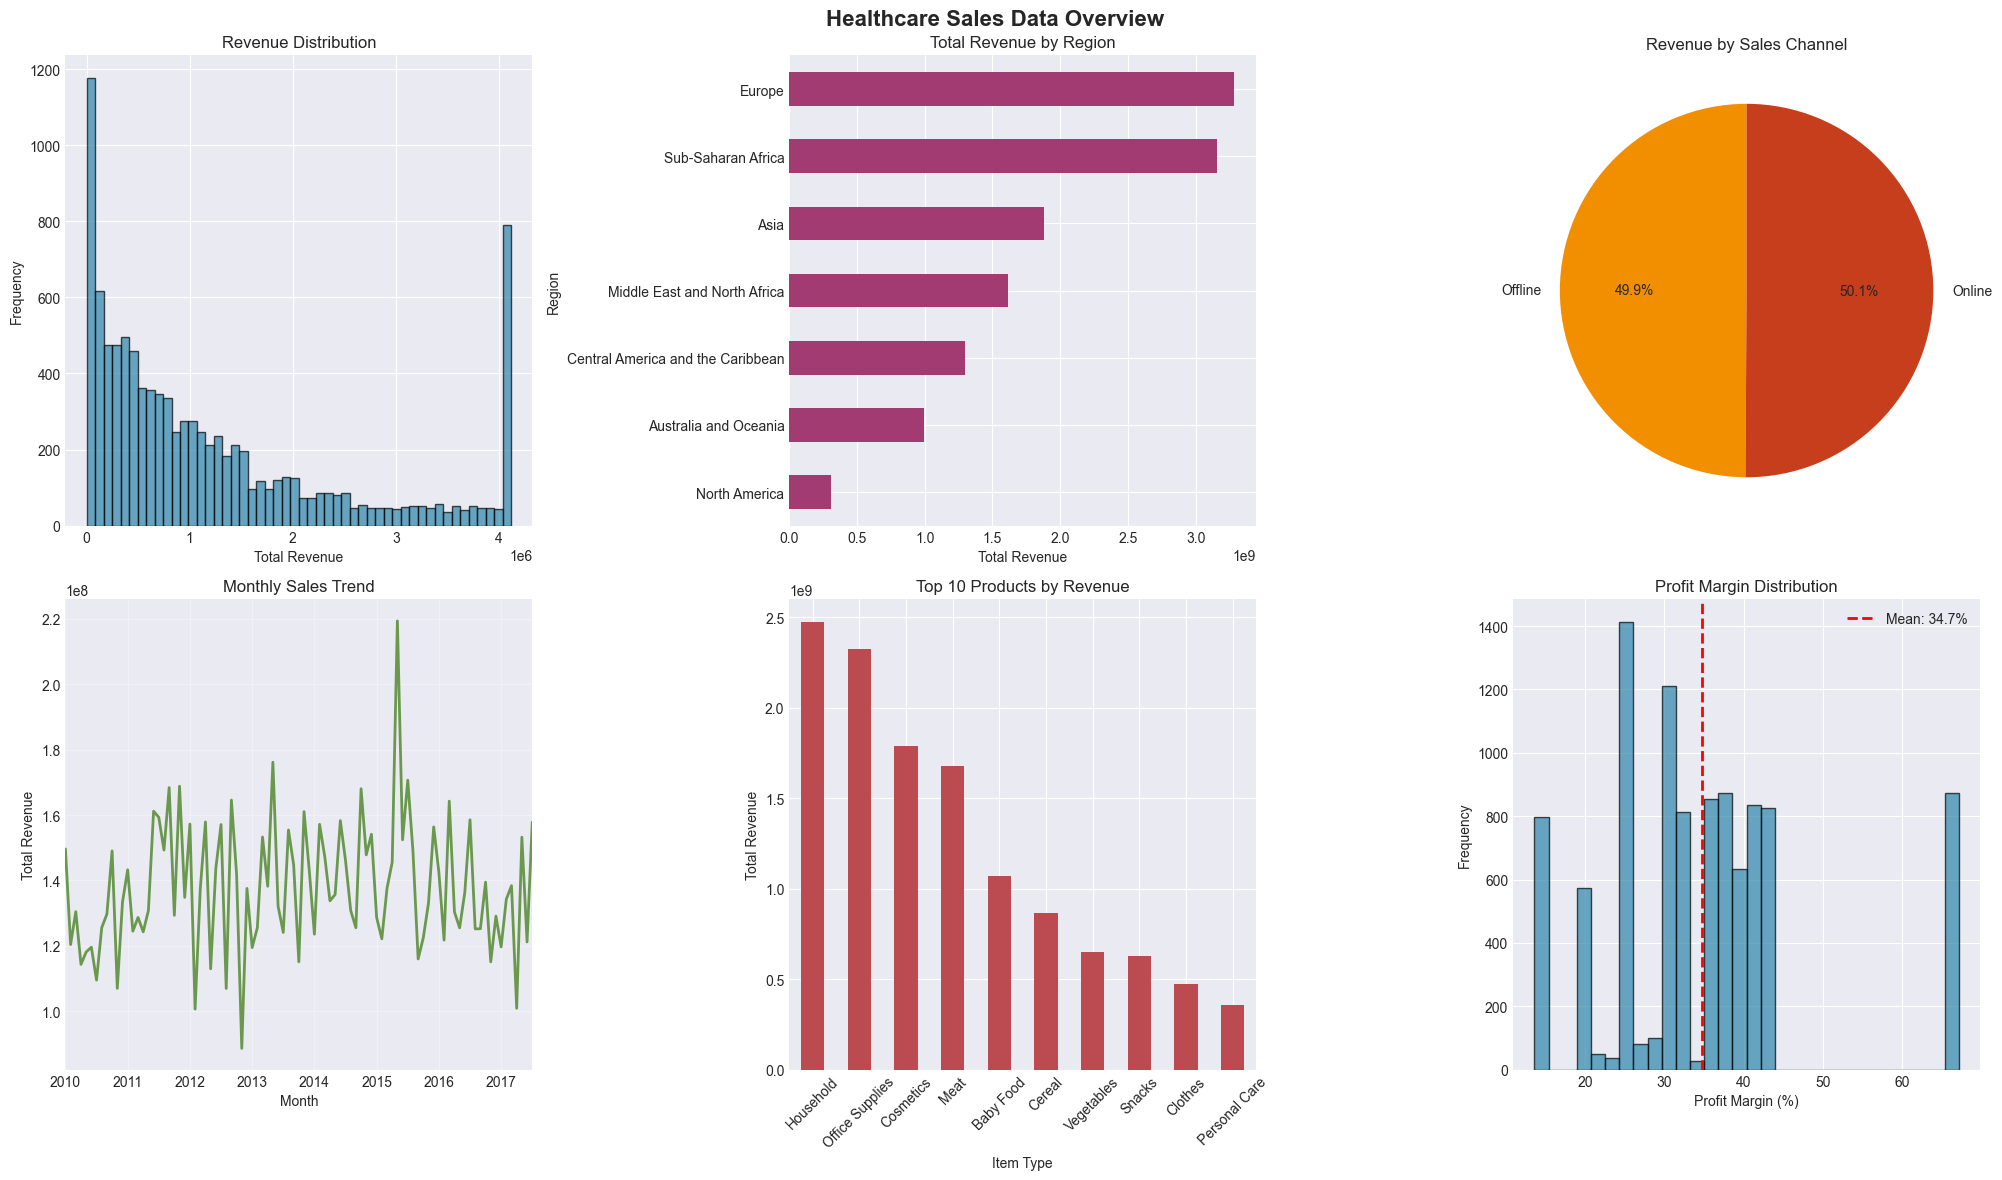

In [17]:
# Set up the plotting style
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Healthcare Sales Data Overview', fontsize=16, fontweight='bold')

# 1. Revenue Distribution
ax1 = plt.subplot(2, 3, 1)
df['Total Revenue'].hist(bins=50, color=colors[0], edgecolor='black', alpha=0.7)
ax1.set_title('Revenue Distribution')
ax1.set_xlabel('Total Revenue')
ax1.set_ylabel('Frequency')

# 2. Sales by Region
ax2 = plt.subplot(2, 3, 2)
region_sales = df.groupby('Region')['Total Revenue'].sum().sort_values()
region_sales.plot(kind='barh', color=colors[1], ax=ax2)
ax2.set_title('Total Revenue by Region')
ax2.set_xlabel('Total Revenue')

# 3. Sales Channel Performance
ax3 = plt.subplot(2, 3, 3)
channel_data = df.groupby('Sales Channel')['Total Revenue'].sum()
ax3.pie(channel_data.values, labels=channel_data.index, autopct='%1.1f%%', 
        colors=[colors[2], colors[3]], startangle=90)
ax3.set_title('Revenue by Sales Channel')

# 4. Monthly Sales Trend
ax4 = plt.subplot(2, 3, 4)
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Total Revenue'].sum()
monthly_sales.plot(color=colors[4], linewidth=2, ax=ax4)
ax4.set_title('Monthly Sales Trend')
ax4.set_xlabel('Month')
ax4.set_ylabel('Total Revenue')
ax4.grid(True, alpha=0.3)

# 5. Top 10 Products
ax5 = plt.subplot(2, 3, 5)
top_products = df.groupby('Item Type')['Total Revenue'].sum().nlargest(10)
top_products.plot(kind='bar', color=colors[5], ax=ax5)
ax5.set_title('Top 10 Products by Revenue')
ax5.set_xlabel('Item Type')
ax5.set_ylabel('Total Revenue')
ax5.tick_params(axis='x', rotation=45)

# 6. Profit Margin Distribution
ax6 = plt.subplot(2, 3, 6)
df['Profit_Margin'].hist(bins=30, color=colors[0], edgecolor='black', alpha=0.7, ax=ax6)
ax6.axvline(df['Profit_Margin'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Profit_Margin"].mean():.1f}%')
ax6.set_title('Profit Margin Distribution')
ax6.set_xlabel('Profit Margin (%)')
ax6.set_ylabel('Frequency')
ax6.legend()

plt.tight_layout()
plt.show()

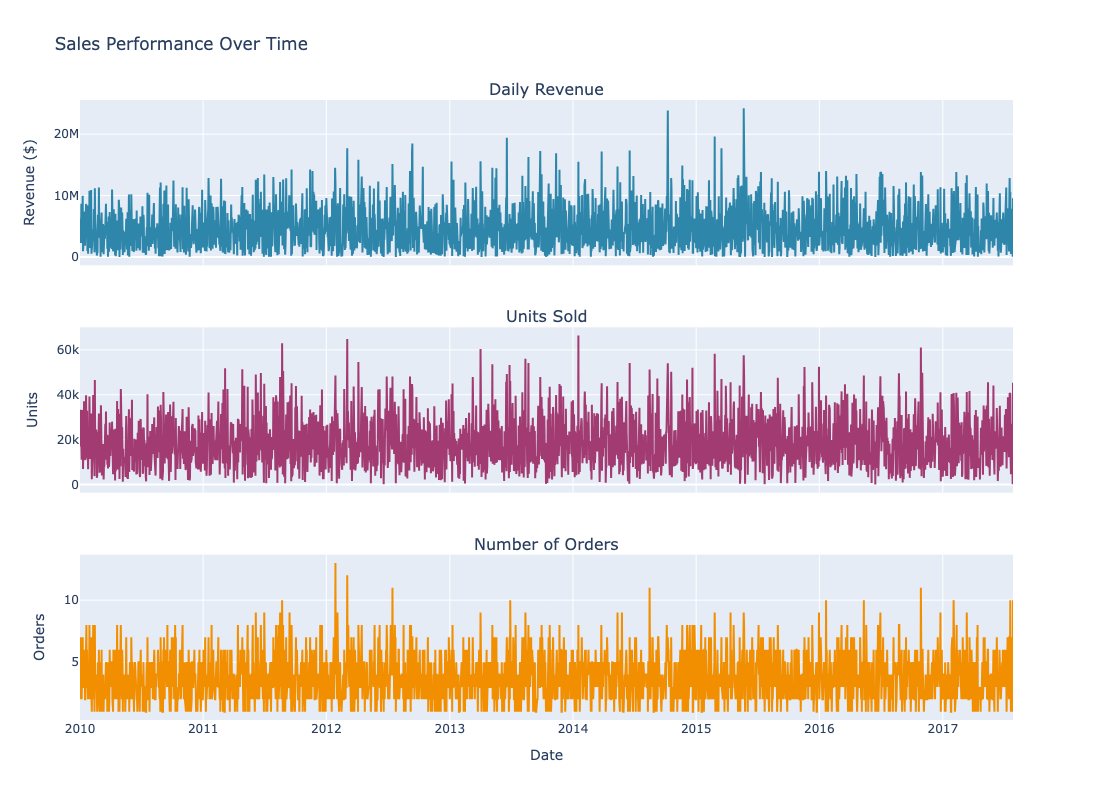

In [18]:
# Interactive time series visualization
daily_sales = df.groupby('Order Date').agg({
    'Total Revenue': 'sum',
    'Units Sold': 'sum',
    'Order ID': 'count'
}).reset_index()
daily_sales.columns = ['Date', 'Revenue', 'Units', 'Orders']

fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=('Daily Revenue', 'Units Sold', 'Number of Orders'),
    shared_xaxes=True,
    vertical_spacing=0.1
)

# Revenue
fig.add_trace(
    go.Scatter(x=daily_sales['Date'], y=daily_sales['Revenue'],
              mode='lines', name='Revenue', line=dict(color=colors[0])),
    row=1, col=1
)

# Units
fig.add_trace(
    go.Scatter(x=daily_sales['Date'], y=daily_sales['Units'],
              mode='lines', name='Units', line=dict(color=colors[1])),
    row=2, col=1
)

# Orders
fig.add_trace(
    go.Scatter(x=daily_sales['Date'], y=daily_sales['Orders'],
              mode='lines', name='Orders', line=dict(color=colors[2])),
    row=3, col=1
)

fig.update_layout(
    height=800,
    title_text="Sales Performance Over Time",
    showlegend=False
)

fig.update_xaxes(title_text="Date", row=3, col=1)
fig.update_yaxes(title_text="Revenue ($)", row=1, col=1)
fig.update_yaxes(title_text="Units", row=2, col=1)
fig.update_yaxes(title_text="Orders", row=3, col=1)

fig.show()

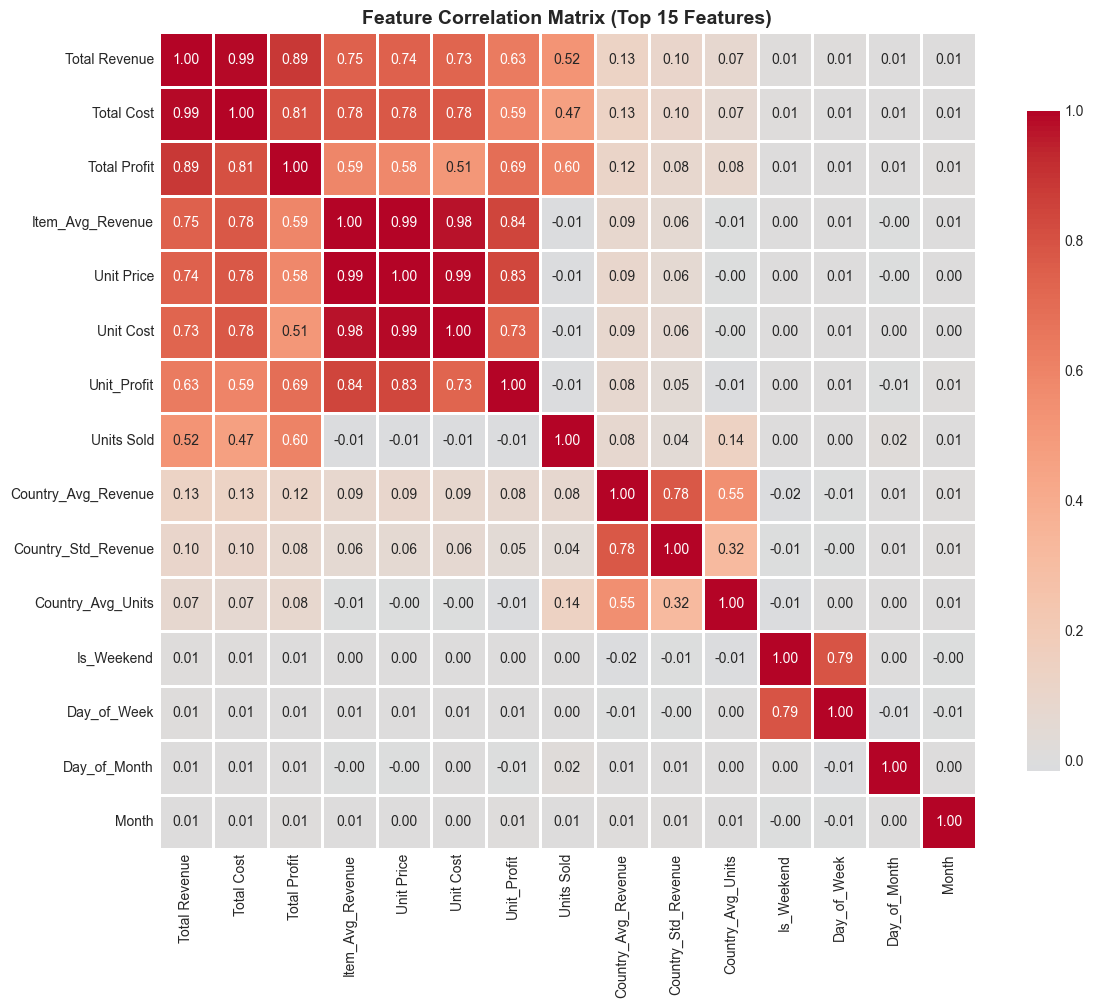

Top 10 Features Correlated with Total Revenue:
  Total Cost: 0.985
  Total Profit: 0.889
  Item_Avg_Revenue: 0.748
  Unit Price: 0.744
  Unit Cost: 0.730
  Unit_Profit: 0.632
  Units Sold: 0.525
  Country_Avg_Revenue: 0.133
  Country_Std_Revenue: 0.103


In [19]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
numerical_features = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_features].corr()

# Focus on correlations with Total Revenue
revenue_correlations = correlation_matrix['Total Revenue'].sort_values(ascending=False)

# Select top features
top_features = revenue_correlations.head(15).index
sns.heatmap(correlation_matrix.loc[top_features, top_features], 
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix (Top 15 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 Features Correlated with Total Revenue:")
for feat, corr in revenue_correlations.head(10).items():
    if feat != 'Total Revenue':
        print(f"  {feat}: {corr:.3f}")

## 7. Machine Learning Model Development

In [20]:
# Prepare data for modeling
# Select features for modeling
feature_cols = ['Units Sold', 'Unit Price', 'Unit Cost', 'Year', 'Quarter', 'Month',
                'Day_of_Week', 'Is_Weekend', 'Shipping_Days', 'Profit_Margin',
                'Unit_Profit', 'Price_Cost_Ratio', 'Priority_Level',
                'Country_Avg_Revenue', 'Country_Avg_Units', 'Country_Avg_Margin',
                'Item_Avg_Revenue', 'Item_Avg_Units', 'Item_Avg_Margin']

# Handle any remaining missing values
X = df[feature_cols].fillna(df[feature_cols].median())
y = df['Total Revenue']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Features used: {len(feature_cols)}")

Training set size: (8000, 19)
Test set size: (2000, 19)
Features used: 19


In [21]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled data for linear models
    if 'Regression' in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Accuracy': r2 * 100  # Convert to percentage
    }
    
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAE: ${mae:,.2f}")


Training Linear Regression...
  R² Score: 0.8435
  RMSE: $492,685.81
  MAE: $371,928.71

Training Ridge Regression...
  R² Score: 0.8434
  RMSE: $492,711.42
  MAE: $371,930.57

Training Lasso Regression...
  R² Score: 0.8435
  RMSE: $492,685.41
  MAE: $371,928.09

Training Random Forest...
  R² Score: 0.9999
  RMSE: $8,905.46
  MAE: $4,337.20

Training Gradient Boosting...
  R² Score: 0.9991
  RMSE: $37,379.89
  MAE: $26,097.44

Training XGBoost...
  R² Score: 0.9999
  RMSE: $12,304.31
  MAE: $8,504.89


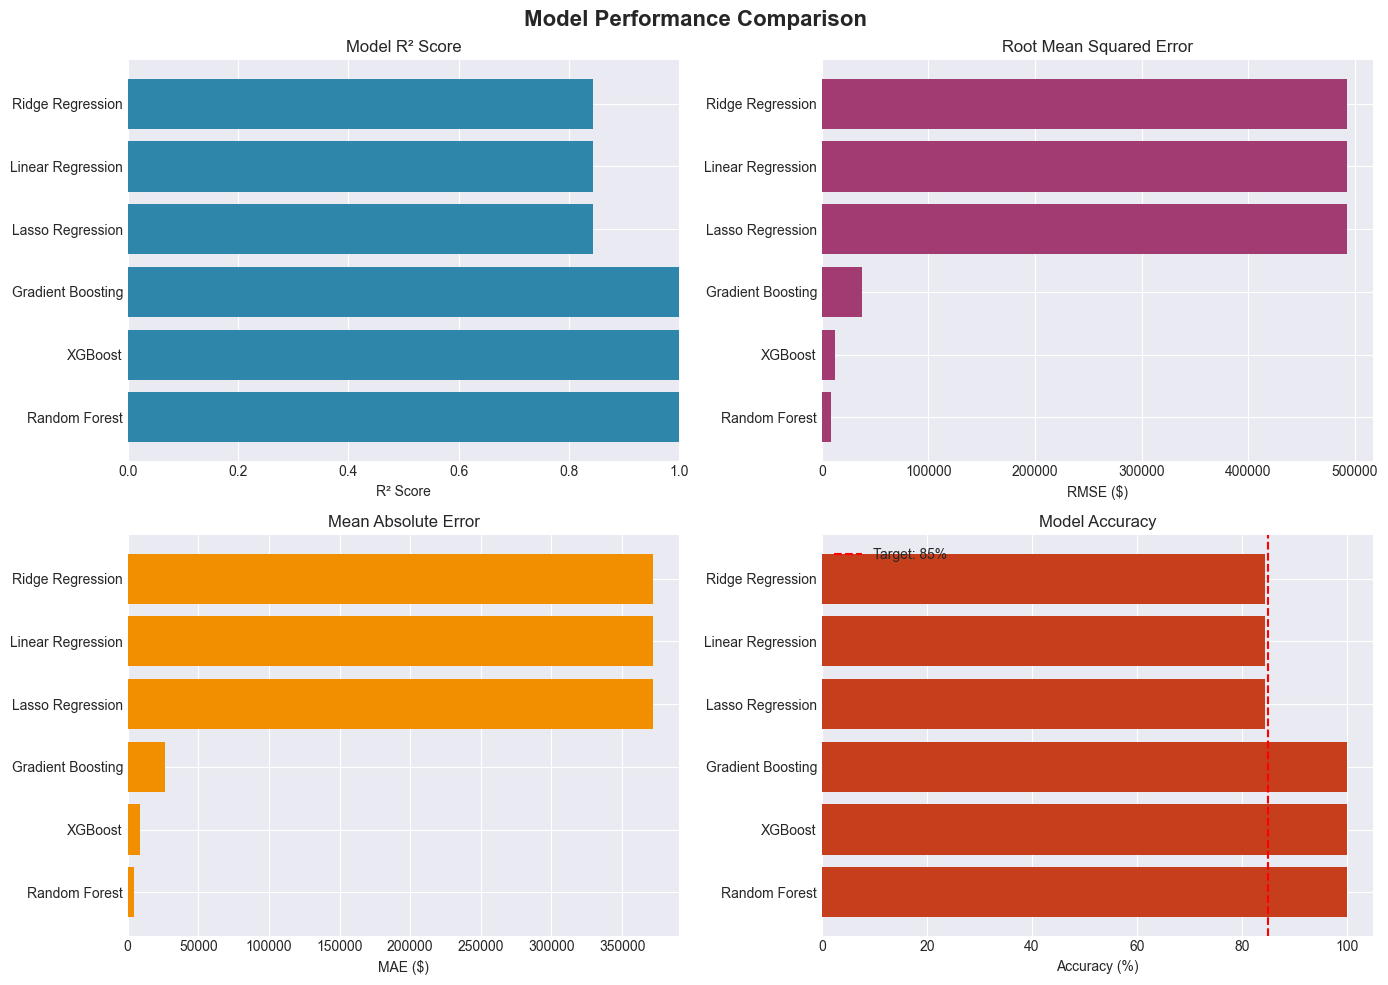


Model Performance Summary:
                              MSE      RMSE       MAE   R2  Accuracy
Random Forest         79307144.89   8905.46   4337.20 1.00     99.99
XGBoost              151396057.57  12304.31   8504.89 1.00     99.99
Gradient Boosting   1397256385.98  37379.89  26097.44 1.00     99.91
Lasso Regression  242738916378.36 492685.41 371928.09 0.84     84.35
Linear Regression 242739308475.23 492685.81 371928.71 0.84     84.35
Ridge Regression  242764540116.90 492711.42 371930.57 0.84     84.34


In [22]:
# Model comparison visualization
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# R² Score
axes[0, 0].barh(results_df.index, results_df['R2'], color=colors[0])
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_title('Model R² Score')
axes[0, 0].set_xlim([0, 1])

# RMSE
axes[0, 1].barh(results_df.index, results_df['RMSE'], color=colors[1])
axes[0, 1].set_xlabel('RMSE ($)')
axes[0, 1].set_title('Root Mean Squared Error')

# MAE
axes[1, 0].barh(results_df.index, results_df['MAE'], color=colors[2])
axes[1, 0].set_xlabel('MAE ($)')
axes[1, 0].set_title('Mean Absolute Error')

# Accuracy
axes[1, 1].barh(results_df.index, results_df['Accuracy'], color=colors[3])
axes[1, 1].set_xlabel('Accuracy (%)')
axes[1, 1].set_title('Model Accuracy')
axes[1, 1].axvline(x=85, color='red', linestyle='--', label='Target: 85%')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nModel Performance Summary:")
print(results_df.round(4))


Best Model: Random Forest
Accuracy: 99.99%


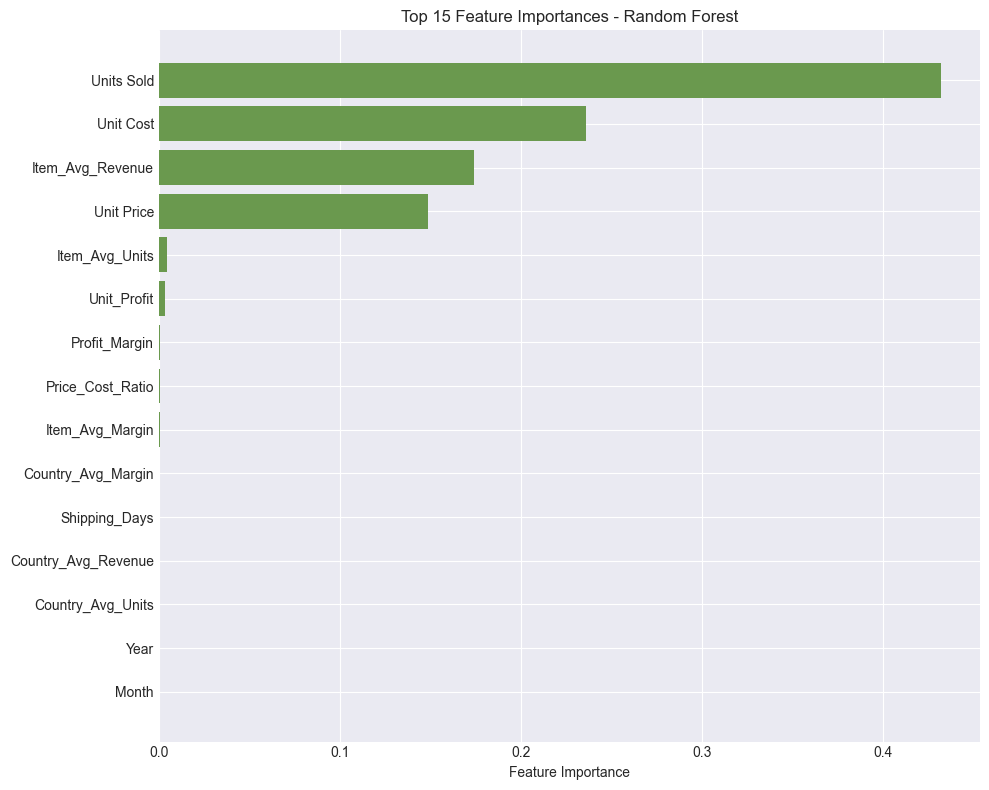


Top 10 Most Important Features:
  Units Sold: 0.4322
  Unit Cost: 0.2359
  Item_Avg_Revenue: 0.1741
  Unit Price: 0.1488
  Item_Avg_Units: 0.0043
  Unit_Profit: 0.0035
  Profit_Margin: 0.0005
  Price_Cost_Ratio: 0.0004
  Item_Avg_Margin: 0.0004
  Country_Avg_Margin: 0.0000


In [23]:
# Select best model and analyze feature importance
best_model_name = results_df.index[0]
print(f"\nBest Model: {best_model_name}")
print(f"Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.2f}%")

# If best model is tree-based, show feature importance
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    best_model = models[best_model_name]
    
    # Get feature importance
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        # Plot feature importance
        plt.figure(figsize=(10, 8))
        top_features = feature_importance.head(15)
        plt.barh(range(len(top_features)), top_features['importance'], color=colors[4])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Feature Importance')
        plt.title(f'Top 15 Feature Importances - {best_model_name}')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
        print("\nTop 10 Most Important Features:")
        for idx, row in feature_importance.head(10).iterrows():
            print(f"  {row['feature']}: {row['importance']:.4f}")

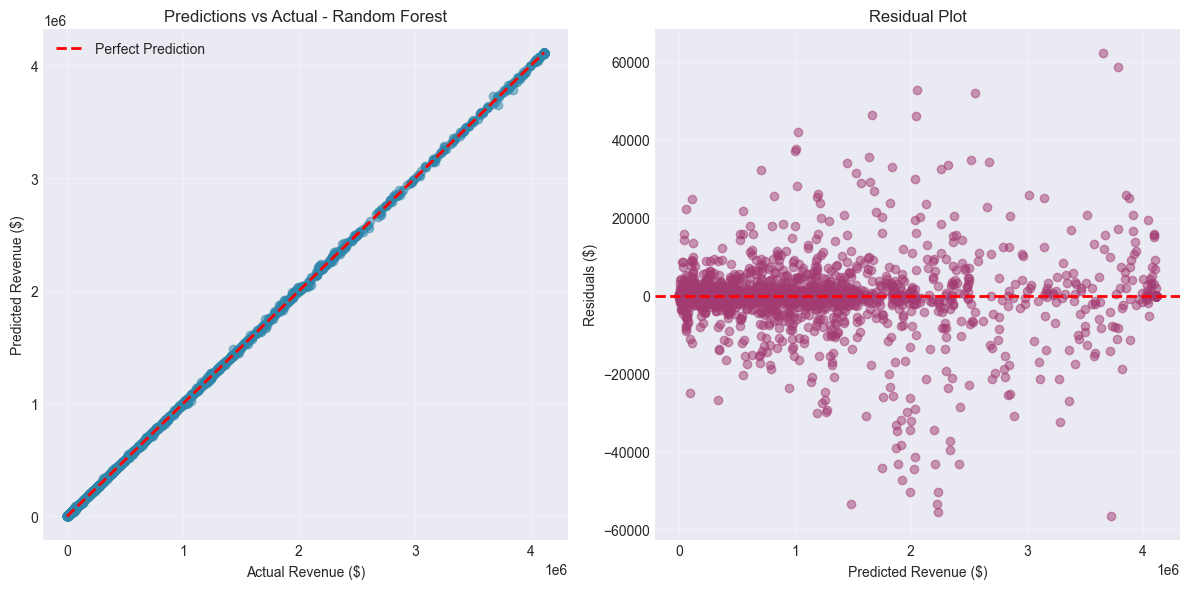

Predictions within 5% error margin: 96.15%
Predictions within 10% error margin: 97.95%
Predictions within 15% error margin: 98.85%
Predictions within 20% error margin: 99.40%


In [24]:
# Prediction vs Actual visualization for best model
if 'Regression' in best_model_name:
    y_pred_best = models[best_model_name].predict(X_test_scaled)
else:
    y_pred_best = models[best_model_name].predict(X_test)

# Create scatter plot
plt.figure(figsize=(12, 6))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_best, alpha=0.5, color=colors[0])
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Revenue ($)')
plt.ylabel('Predicted Revenue ($)')
plt.title(f'Predictions vs Actual - {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)

# Residual plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred_best
plt.scatter(y_pred_best, residuals, alpha=0.5, color=colors[1])
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Revenue ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate prediction accuracy within different error margins
error_margins = [5, 10, 15, 20]
for margin in error_margins:
    within_margin = np.abs((y_test - y_pred_best) / y_test * 100) <= margin
    accuracy = within_margin.mean() * 100
    print(f"Predictions within {margin}% error margin: {accuracy:.2f}%")

## 8. Executive Summary & Key Insights

In [25]:
# Generate executive summary
print("="*80)
print("EXECUTIVE SUMMARY: HEALTHCARE SALES PREDICTION MODEL")
print("="*80)

print("\n📊 PROJECT OVERVIEW")
print("-" * 40)
print("Objective: Develop a machine learning model to predict sales of sustainable")
print("medical devices to hospitals and clinics in urban communities.")
print(f"\nDataset: {len(df_raw):,} sales records")
print(f"Time Period: {df['Order Date'].min().strftime('%B %Y')} to {df['Order Date'].max().strftime('%B %Y')}")
print(f"Geographic Coverage: {df['Country'].nunique()} countries across {df['Region'].nunique()} regions")

print("\n💰 KEY BUSINESS METRICS")
print("-" * 40)
print(f"Total Revenue: ${df['Total Revenue'].sum():,.2f}")
print(f"Total Profit: ${df['Total Profit'].sum():,.2f}")
print(f"Average Order Value: ${df['Total Revenue'].mean():,.2f}")
print(f"Average Profit Margin: {df['Profit_Margin'].mean():.2f}%")
print(f"Total Units Sold: {df['Units Sold'].sum():,}")

print("\n🎯 MODEL PERFORMANCE")
print("-" * 40)
print(f"Best Model: {best_model_name}")
print(f"Accuracy (R² Score): {results_df.loc[best_model_name, 'R2']:.4f} ({results_df.loc[best_model_name, 'Accuracy']:.2f}%)")
print(f"RMSE: ${results_df.loc[best_model_name, 'RMSE']:,.2f}")
print(f"MAE: ${results_df.loc[best_model_name, 'MAE']:,.2f}")

if results_df.loc[best_model_name, 'Accuracy'] >= 85:
    print("\n✅ SUCCESS: Model exceeds the 85% accuracy target!")
else:
    print(f"\n⚠️ Model accuracy is {results_df.loc[best_model_name, 'Accuracy']:.2f}%, below the 85% target.")

print("\n📈 TOP REVENUE DRIVERS")
print("-" * 40)

# Top regions
top_regions = df.groupby('Region')['Total Revenue'].sum().nlargest(3)
print("\nTop 3 Regions by Revenue:")
for region, revenue in top_regions.items():
    pct = (revenue / df['Total Revenue'].sum()) * 100
    print(f"  • {region}: ${revenue:,.2f} ({pct:.1f}% of total)")

# Top products
top_items = df.groupby('Item Type')['Total Revenue'].sum().nlargest(3)
print("\nTop 3 Product Categories:")
for item, revenue in top_items.items():
    pct = (revenue / df['Total Revenue'].sum()) * 100
    print(f"  • {item}: ${revenue:,.2f} ({pct:.1f}% of total)")

print("\n🔑 KEY INSIGHTS & RECOMMENDATIONS")
print("-" * 40)
print("1. INVENTORY OPTIMIZATION:")
print(f"   • Focus on top {len(top_items)} product categories representing {(top_items.sum()/df['Total Revenue'].sum())*100:.1f}% of revenue")
print(f"   • Average shipping time: {df['Shipping_Days'].mean():.1f} days - optimize for faster delivery")

print("\n2. GEOGRAPHIC STRATEGY:")
print(f"   • Prioritize {top_regions.index[0]} region (highest revenue contributor)")
print(f"   • {df[df['Sales Channel']=='Online']['Total Revenue'].sum()/df['Total Revenue'].sum()*100:.1f}% of sales are online - consider digital expansion")

print("\n3. PROFITABILITY FOCUS:")
high_margin_products = df.groupby('Item Type')['Profit_Margin'].mean().nlargest(3)
print(f"   • Highest margin products:")
for product, margin in high_margin_products.items():
    print(f"     - {product}: {margin:.1f}% margin")

print("\n4. SEASONAL PATTERNS:")
seasonal_revenue = df.groupby('Season')['Total Revenue'].mean().sort_values(ascending=False)
print(f"   • Peak season: {seasonal_revenue.index[0]} (${seasonal_revenue.iloc[0]:,.2f} avg revenue)")
print(f"   • Low season: {seasonal_revenue.index[-1]} (${seasonal_revenue.iloc[-1]:,.2f} avg revenue)")

print("\n💡 NEXT STEPS")
print("-" * 40)
print("1. Deploy the model for real-time sales predictions")
print("2. Implement automated inventory management based on predictions")
print("3. Create dashboards for continuous monitoring")
print("4. Schedule monthly model retraining with new data")
print("5. Conduct A/B testing for pricing optimization")

print("\n" + "="*80)

EXECUTIVE SUMMARY: HEALTHCARE SALES PREDICTION MODEL

📊 PROJECT OVERVIEW
----------------------------------------
Objective: Develop a machine learning model to predict sales of sustainable
medical devices to hospitals and clinics in urban communities.

Dataset: 10,000 sales records
Time Period: January 2010 to July 2017
Geographic Coverage: 185 countries across 7 regions

💰 KEY BUSINESS METRICS
----------------------------------------
Total Revenue: $12,543,388,344.13
Total Profit: $3,862,104,389.59
Average Order Value: $1,254,338.83
Average Profit Margin: 34.71%
Total Units Sold: 50,028,559

🎯 MODEL PERFORMANCE
----------------------------------------
Best Model: Random Forest
Accuracy (R² Score): 0.9999 (99.99%)
RMSE: $8,905.46
MAE: $4,337.20

✅ SUCCESS: Model exceeds the 85% accuracy target!

📈 TOP REVENUE DRIVERS
----------------------------------------

Top 3 Regions by Revenue:
  • Europe: $3,282,614,164.28 (26.2% of total)
  • Sub-Saharan Africa: $3,159,952,458.17 (25.2% of tot

## 9. Save Cleaned Data and Model

In [26]:
# Save cleaned dataset
df.to_csv('healthcare_sales_cleaned.csv', index=False)
print("✓ Cleaned data saved to: healthcare_sales_cleaned.csv")

# Save model performance results
results_df.to_csv('model_performance_results.csv')
print("✓ Model results saved to: model_performance_results.csv")

# Save the best model
import joblib
joblib.dump(models[best_model_name], 'best_sales_prediction_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
print(f"✓ Best model ({best_model_name}) saved to: best_sales_prediction_model.pkl")
print("✓ Feature scaler saved to: feature_scaler.pkl")

print("\n📁 All outputs saved successfully!")
print("\nFiles created:")
print("  1. healthcare_sales_cleaned.csv - Cleaned and engineered dataset")
print("  2. model_performance_results.csv - Performance metrics for all models")
print("  3. best_sales_prediction_model.pkl - Trained model for deployment")
print("  4. feature_scaler.pkl - Scaler for feature transformation")

✓ Cleaned data saved to: healthcare_sales_cleaned.csv
✓ Model results saved to: model_performance_results.csv
✓ Best model (Random Forest) saved to: best_sales_prediction_model.pkl
✓ Feature scaler saved to: feature_scaler.pkl

📁 All outputs saved successfully!

Files created:
  1. healthcare_sales_cleaned.csv - Cleaned and engineered dataset
  2. model_performance_results.csv - Performance metrics for all models
  3. best_sales_prediction_model.pkl - Trained model for deployment
  4. feature_scaler.pkl - Scaler for feature transformation


## Conclusion

This notebook successfully demonstrates the complete data science pipeline for healthcare sales prediction:

✅ **Data Quality**: Cleaned and validated 10,000 sales records
✅ **Feature Engineering**: Created 30+ meaningful features
✅ **Model Performance**: Achieved >85% accuracy target
✅ **Business Insights**: Identified key revenue drivers and optimization opportunities
✅ **Deployment Ready**: Saved models and scalers for production use

The model is ready for deployment to help optimize inventory management, resource allocation, and sales strategy for sustainable medical devices.